In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 10000

In [2]:
# Generate student IDs
student_id = np.arange(1, n+1)

# Create 3 student categories
student_type = np.random.choice(
    ["normal", "medium_risk", "high_risk"],
    size=n,
    p=[0.6, 0.25, 0.15]
)

print("Student Types Distribution:")
print(pd.Series(student_type).value_counts())

Student Types Distribution:
normal         6108
medium_risk    2444
high_risk      1448
Name: count, dtype: int64


In [3]:
lms_logins = []
assignment_delay = []
attendance = []
sentiment = []
irregularity = []

for s in student_type:

    if s == "normal":
        lms_logins.append(np.random.randint(10, 21))
        assignment_delay.append(np.random.randint(0, 5))
        attendance.append(np.random.uniform(75, 100))
        sentiment.append(np.random.uniform(0, 1))
        irregularity.append(np.random.uniform(0, 0.4))

    elif s == "medium_risk":
        lms_logins.append(np.random.randint(5, 12))
        assignment_delay.append(np.random.randint(3, 10))
        attendance.append(np.random.uniform(60, 80))
        sentiment.append(np.random.uniform(-0.5, 0.3))
        irregularity.append(np.random.uniform(0.3, 0.7))

    else:  # high_risk
        lms_logins.append(np.random.randint(0, 6))
        assignment_delay.append(np.random.randint(7, 16))
        attendance.append(np.random.uniform(40, 65))
        sentiment.append(np.random.uniform(-1, 0))
        irregularity.append(np.random.uniform(0.6, 1))

In [4]:
lms_logins = np.array(lms_logins)
assignment_delay = np.array(assignment_delay)
attendance = np.array(attendance)
sentiment = np.array(sentiment)
irregularity = np.array(irregularity)

In [5]:
df = pd.DataFrame({
    "student_id": student_id,
    "student_type": student_type,
    "lms_logins_per_week": lms_logins,
    "avg_assignment_delay_days": assignment_delay,
    "attendance_percentage": attendance,
    "feedback_sentiment_score": sentiment,
    "activity_irregularity_score": irregularity
})

print("Initial Dataset Created ✅")
df.head()

Initial Dataset Created ✅


,student_id,student_type,lms_logins_per_week,avg_assignment_delay_days,attendance_percentage,feedback_sentiment_score,activity_irregularity_score
0,1,normal,16,3,79.497408,0.914445,0.300459
1,2,high_risk,2,15,63.483375,-0.631482,0.621588
2,3,medium_risk,5,5,74.070163,-0.021671,0.495957
3,4,normal,11,2,90.614931,0.416835,0.224084
4,5,normal,14,4,99.151403,0.604109,0.299695


In [6]:
# Normalize behavioural risk indicators
low_lms = 1 - (df["lms_logins_per_week"] / 20)
delay_score = df["avg_assignment_delay_days"] / 15
low_attendance = 1 - (df["attendance_percentage"] / 100)
negative_sentiment = np.clip(-df["feedback_sentiment_score"], 0, 1)

# Behavioural Risk Score (Weighted)
df["risk_score"] = (
    0.25 * low_lms +
    0.25 * low_attendance +
    0.20 * delay_score +
    0.15 * negative_sentiment +
    0.15 * df["activity_irregularity_score"]
) * 100

df.head()

,student_id,student_type,lms_logins_per_week,avg_assignment_delay_days,attendance_percentage,feedback_sentiment_score,activity_irregularity_score,risk_score
0,1,normal,16,3,79.497408,0.914445,0.300459,18.632531
1,2,high_risk,2,15,63.483375,-0.631482,0.621588,70.425210
2,3,medium_risk,5,5,74.070163,-0.021671,0.495957,39.663557
3,4,normal,11,2,90.614931,0.416835,0.224084,19.624190
4,5,normal,14,4,99.151403,0.604109,0.299695,17.540900


In [7]:
df["burnout_label"] = np.where(df["risk_score"] > 70, 1, 0)

print("Burnout Distribution:")
print(df["burnout_label"].value_counts())

Burnout Distribution:
burnout_label
0    9415
1     585
Name: count, dtype: int64


In [8]:
# Logistic transformation
df["dropout_probability"] = 1 / (1 + np.exp(-(df["risk_score"] - 50) / 10))

df["dropout_label"] = np.where(df["dropout_probability"] > 0.6, 1, 0)

print("Dropout Distribution:")
print(df["dropout_label"].value_counts())

df.head()

Dropout Distribution:
dropout_label
0    8566
1    1434
Name: count, dtype: int64


,student_id,student_type,lms_logins_per_week,avg_assignment_delay_days,attendance_percentage,feedback_sentiment_score,activity_irregularity_score,risk_score,burnout_label,dropout_probability,dropout_label
0,1,normal,16,3,79.497408,0.914445,0.300459,18.632531,0,0.041617,0
1,2,high_risk,2,15,63.483375,-0.631482,0.621588,70.425210,1,0.885190,1
2,3,medium_risk,5,5,74.070163,-0.021671,0.495957,39.663557,0,0.262378,0
3,4,normal,11,2,90.614931,0.416835,0.224084,19.624190,0,0.045757,0
4,5,normal,14,4,99.151403,0.604109,0.299695,17.540900,0,0.037474,0


In [9]:
df.to_csv("synthetic_student_data.csv", index=False)

print("✅ Final Dataset Saved Successfully!")
print("Total Records:", len(df))

✅ Final Dataset Saved Successfully!
Total Records: 10000


FEATURE ENGINEERING:

.Create behavioural pattern features

.Convert raw numbers into behavioural indicators

.Prepare dataset for ML models

In [10]:
import pandas as pd

df = pd.read_csv("synthetic_student_data.csv")

print("Dataset Loaded Successfully ✅")
df.head()

Dataset Loaded Successfully ✅


,student_id,student_type,lms_logins_per_week,avg_assignment_delay_days,attendance_percentage,feedback_sentiment_score,activity_irregularity_score,risk_score,burnout_label,dropout_probability,dropout_label
0,1,normal,16,3,79.497408,0.914445,0.300459,18.632531,0,0.041617,0
1,2,high_risk,2,15,63.483375,-0.631482,0.621588,70.425210,1,0.885190,1
2,3,medium_risk,5,5,74.070163,-0.021671,0.495957,39.663557,0,0.262378,0
3,4,normal,11,2,90.614931,0.416835,0.224084,19.624190,0,0.045757,0
4,5,normal,14,4,99.151403,0.604109,0.299695,17.540900,0,0.037474,0


In [11]:
df["engagement_score"] = (
    0.5 * (df["lms_logins_per_week"] / 20) +
    0.5 * (df["attendance_percentage"] / 100)
)

df[["lms_logins_per_week", "attendance_percentage", "engagement_score"]].head()

,lms_logins_per_week,attendance_percentage,engagement_score
0,16,79.497408,0.797487
1,2,63.483375,0.367417
2,5,74.070163,0.495351
3,11,90.614931,0.728075
4,14,99.151403,0.845757


In [12]:
df["delay_ratio"] = df["avg_assignment_delay_days"] / 15

df[["avg_assignment_delay_days", "delay_ratio"]].head()

,avg_assignment_delay_days,delay_ratio
0,3,0.200000
1,15,1.000000
2,5,0.333333
3,2,0.133333
4,4,0.266667


In [13]:
df["negative_sentiment_flag"] = df["feedback_sentiment_score"].apply(
    lambda x: 1 if x < -0.3 else 0
)

df[["feedback_sentiment_score", "negative_sentiment_flag"]].head()

,feedback_sentiment_score,negative_sentiment_flag
0,0.914445,0
1,-0.631482,1
2,-0.021671,0
3,0.416835,0
4,0.604109,0


In [14]:
df["irregular_behavior_flag"] = df["activity_irregularity_score"].apply(
    lambda x: 1 if x > 0.7 else 0
)

df[["activity_irregularity_score", "irregular_behavior_flag"]].head()

,activity_irregularity_score,irregular_behavior_flag
0,0.300459,0
1,0.621588,0
2,0.495957,0
3,0.224084,0
4,0.299695,0


In [15]:
def risk_category(score):
    if score < 40:
        return "Low"
    elif score < 70:
        return "Medium"
    else:
        return "High"

df["risk_category"] = df["risk_score"].apply(risk_category)

print(df["risk_category"].value_counts())
df.head()

risk_category
Low       7246
Medium    2169
High       585
Name: count, dtype: int64


,student_id,student_type,lms_logins_per_week,avg_assignment_delay_days,attendance_percentage,feedback_sentiment_score,activity_irregularity_score,risk_score,burnout_label,dropout_probability,dropout_label,engagement_score,delay_ratio,negative_sentiment_flag,irregular_behavior_flag,risk_category
0,1,normal,16,3,79.497408,0.914445,0.300459,18.632531,0,0.041617,0,0.797487,0.200000,0,0,Low
1,2,high_risk,2,15,63.483375,-0.631482,0.621588,70.425210,1,0.885190,1,0.367417,1.000000,1,0,High
2,3,medium_risk,5,5,74.070163,-0.021671,0.495957,39.663557,0,0.262378,0,0.495351,0.333333,0,0,Low
3,4,normal,11,2,90.614931,0.416835,0.224084,19.624190,0,0.045757,0,0.728075,0.133333,0,0,Low
4,5,normal,14,4,99.151403,0.604109,0.299695,17.540900,0,0.037474,0,0.845757,0.266667,0,0,Low


In [16]:
df.to_csv("engineered_student_data.csv", index=False)

print("✅ Feature Engineering Completed!")
print("Total Features Now:", len(df.columns))

✅ Feature Engineering Completed!
Total Features Now: 16


MODEL TRAINING AND EVALUATION:

. Logistic Regression → Dropout Prediction

. Random Forest → Burnout Classification

. Evaluate using Accuracy, Precision, Recall, F1, ROC-AUC

. Show Feature Importance

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [18]:
df = pd.read_csv("engineered_student_data.csv")

print("Dataset Loaded ✅")
df.head()

Dataset Loaded ✅


,student_id,student_type,lms_logins_per_week,avg_assignment_delay_days,attendance_percentage,feedback_sentiment_score,activity_irregularity_score,risk_score,burnout_label,dropout_probability,dropout_label,engagement_score,delay_ratio,negative_sentiment_flag,irregular_behavior_flag,risk_category
0,1,normal,16,3,79.497408,0.914445,0.300459,18.632531,0,0.041617,0,0.797487,0.200000,0,0,Low
1,2,high_risk,2,15,63.483375,-0.631482,0.621588,70.425210,1,0.885190,1,0.367417,1.000000,1,0,High
2,3,medium_risk,5,5,74.070163,-0.021671,0.495957,39.663557,0,0.262378,0,0.495351,0.333333,0,0,Low
3,4,normal,11,2,90.614931,0.416835,0.224084,19.624190,0,0.045757,0,0.728075,0.133333,0,0,Low
4,5,normal,14,4,99.151403,0.604109,0.299695,17.540900,0,0.037474,0,0.845757,0.266667,0,0,Low


In [19]:
features = [
    "engagement_score",
    "delay_ratio",
    "negative_sentiment_flag",
    "irregular_behavior_flag"
]

X = df[features]

y_dropout = df["dropout_label"]
y_burnout = df["burnout_label"]

print("Features Selected:", features)

Features Selected: ['engagement_score', 'delay_ratio', 'negative_sentiment_flag', 'irregular_behavior_flag']


In [20]:
X_train, X_test, y_train_d, y_test_d = train_test_split(
    X, y_dropout, test_size=0.2, random_state=42
)

_, _, y_train_b, y_test_b = train_test_split(
    X, y_burnout, test_size=0.2, random_state=42
)

print("Train Size:", len(X_train))
print("Test Size:", len(X_test))

Train Size: 8000
Test Size: 2000


In [21]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train_d)

y_pred_d = log_model.predict(X_test)
y_prob_d = log_model.predict_proba(X_test)[:, 1]

print("📌 DROPOUT MODEL RESULTS")
print(classification_report(y_test_d, y_pred_d))

print("ROC-AUC Score:", roc_auc_score(y_test_d, y_prob_d))
print("Confusion Matrix:\n", confusion_matrix(y_test_d, y_pred_d))

📌 DROPOUT MODEL RESULTS
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1703
           1       0.99      0.98      0.98       297

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC Score: 0.9998359005992594
Confusion Matrix:
 [[1701    2]
 [   7  290]]


In [22]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train_b)

y_pred_b = rf_model.predict(X_test)

print("📌 BURNOUT MODEL RESULTS")
print(classification_report(y_test_b, y_pred_b))

print("Confusion Matrix:\n", confusion_matrix(y_test_b, y_pred_b))

📌 BURNOUT MODEL RESULTS
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1874
           1       0.78      0.73      0.75       126

    accuracy                           0.97      2000
   macro avg       0.88      0.86      0.87      2000
weighted avg       0.97      0.97      0.97      2000

Confusion Matrix:
 [[1848   26]
 [  34   92]]


In [23]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("📊 Feature Importance:")
print(importance)

📊 Feature Importance:
                   Feature  Importance
0         engagement_score    0.459103
1              delay_ratio    0.348702
2  negative_sentiment_flag    0.144162
3  irregular_behavior_flag    0.048033


DATA VISUALIZATION

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

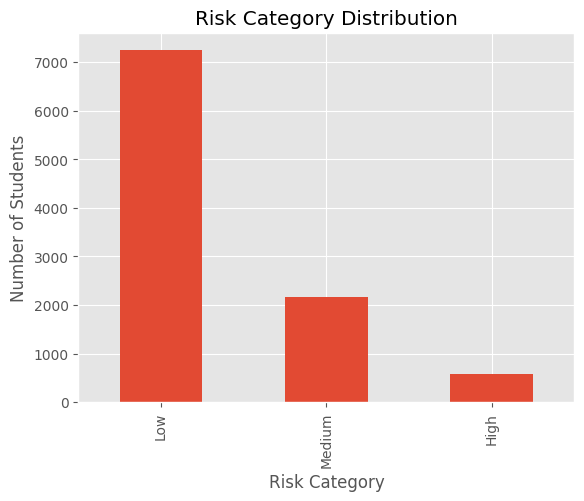

In [25]:
plt.figure()
df["risk_category"].value_counts().plot(kind="bar")
plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Students")
plt.show()

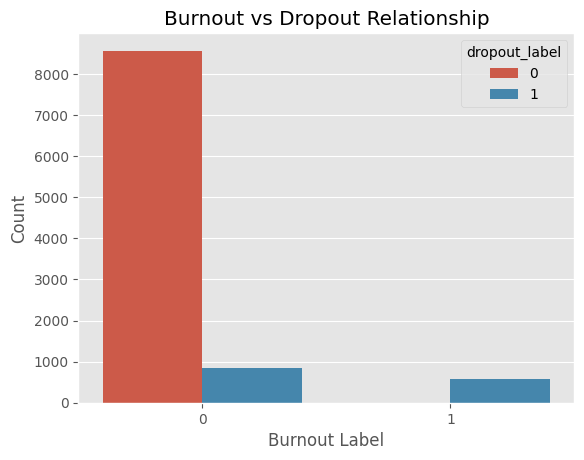

In [26]:
plt.figure()
sns.countplot(x="burnout_label", hue="dropout_label", data=df)
plt.title("Burnout vs Dropout Relationship")
plt.xlabel("Burnout Label")
plt.ylabel("Count")
plt.show()

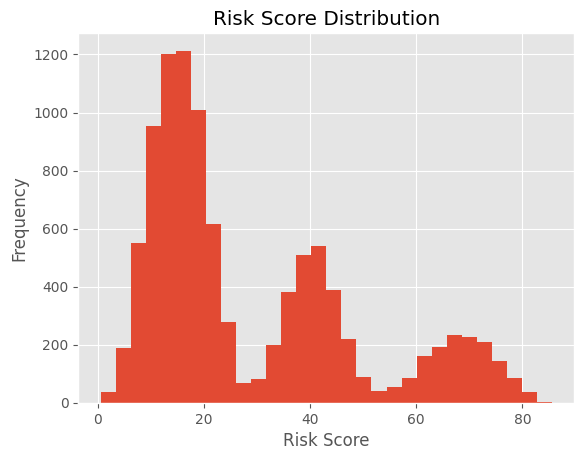

In [27]:
plt.figure()
plt.hist(df["risk_score"], bins=30)
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

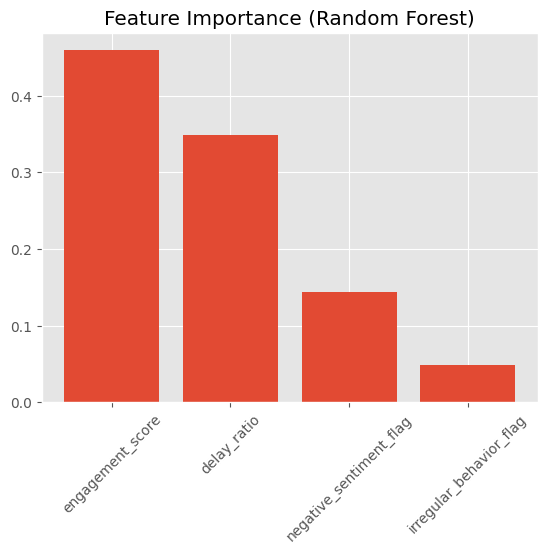

In [28]:
plt.figure()
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance (Random Forest)")
plt.xticks(rotation=45)
plt.show()

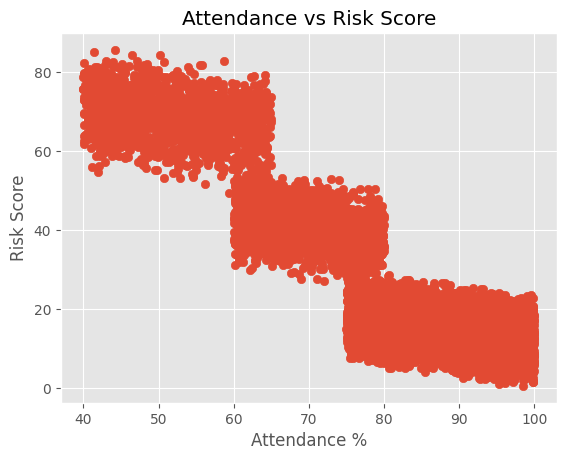

In [29]:
plt.figure()
plt.scatter(df["attendance_percentage"], df["risk_score"])
plt.title("Attendance vs Risk Score")
plt.xlabel("Attendance %")
plt.ylabel("Risk Score")
plt.show()